# Does 730-day history add anything beyond 365-day history?

The previous experiment showed that adding 365-day history improved the previous-inspection-only baseline (test PR-AUC 0.127 to 0.162, ROC-AUC 0.644 to 0.704). This notebook tests whether going back further, to 730 days, adds anything more on top of that.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_score,
                              recall_score, f1_score, accuracy_score, confusion_matrix,
                              precision_recall_curve, roc_curve)

pred = pd.read_csv("../outputs/prediction_events_current_v1.csv",
                    parse_dates=["inspectionDate", "prev_inspectionDate"], low_memory=False)
long = pd.read_csv("../outputs/inspection_level_longitudinal.csv",
                    parse_dates=["inspectionDate"], low_memory=False)
long = long.sort_values(["estId", "inspectionDate"]).reset_index(drop=True)
print("prediction rows:", len(pred))

prediction rows: 69766


## Building the 730-day features

`prediction_events_current_v1.csv` already has the 365-day features but not 730-day ones, so those are calculated from the longitudinal table and merged in. Same approach as the 365-day version: for a target at date `t`, only inspections with `t - 730 days <= inspection date < t` count, using the previous inspection's date as the reference, never the target inspection itself.

In [2]:
long["is_non_pass"] = long["inspectionStatus"].isin(["Conditional Pass", "Closed"]).astype(int)

def rolling_730(g):
    g = g.reset_index()
    dates = g["inspectionDate"].values.astype("datetime64[D]")
    total_infr = g["n_infractions"].to_numpy()
    crucial = g["n_crucial"].to_numpy()
    non_pass = g["is_non_pass"].to_numpy()

    cs_infr = np.concatenate([[0], np.cumsum(total_infr)])
    cs_crucial = np.concatenate([[0], np.cumsum(crucial)])
    cs_nonpass = np.concatenate([[0], np.cumsum(non_pass)])

    lower_edge = dates - np.timedelta64(730, "D")
    low_idx = np.searchsorted(dates, lower_edge, side="left")

    idx_arr = np.arange(len(g))
    return pd.DataFrame({
        "orig_index": g["index"],
        "prior_730d_n_inspections": idx_arr - low_idx,
        "prior_730d_n_non_pass": cs_nonpass[idx_arr] - cs_nonpass[low_idx],
        "prior_730d_total_infractions": cs_infr[idx_arr] - cs_infr[low_idx],
        "prior_730d_crucial_infractions": cs_crucial[idx_arr] - cs_crucial[low_idx],
    })

rolled = long.groupby("estId", group_keys=False).apply(rolling_730).set_index("orig_index")
long_feat = long.join(rolled)

hist_730 = long_feat[["estId", "inspectionDate", "prior_730d_n_inspections", "prior_730d_n_non_pass",
                       "prior_730d_total_infractions", "prior_730d_crucial_infractions"]]

df = pred.merge(hist_730, on=["estId", "inspectionDate"], how="left")
print("merged rows:", len(df))
assert len(df) == len(pred)

merged rows: 69766


## Validating the new features

Same brute-force approach as the earlier notebooks: recompute the 730-day counts directly for a random sample and compare, plus a few basic sanity checks.

In [3]:
HIST730 = ["prior_730d_n_inspections", "prior_730d_n_non_pass",
           "prior_730d_total_infractions", "prior_730d_crucial_infractions"]

for c in HIST730:
    assert df[c].notna().all()
    assert (df[c] >= 0).all()
    print(c, df[c].dtype, "min", df[c].min(), "max", df[c].max())

assert not df.duplicated(subset=["estId", "inspectionDate"]).any()
assert (df["inspectionDate"] > df["prev_inspectionDate"]).all()
assert df["inspectionDate"].min() >= pd.Timestamp("2023-11-10")
assert df["inspectionDate"].max() <= pd.Timestamp("2026-09-08")

prior_730d_n_inspections int64 min 0 max 14
prior_730d_n_non_pass int64 min 0 max 8
prior_730d_total_infractions int64 min 0 max 76
prior_730d_crucial_infractions int64 min 0 max 13


In [4]:
rng = np.random.default_rng(0)
sample_idx = rng.choice(df.index, size=300, replace=False)

mismatches = 0
for i in sample_idx:
    row = df.loc[i]
    hist = long[(long["estId"] == row["estId"]) & (long["inspectionDate"] < row["inspectionDate"])]
    window = hist[hist["inspectionDate"] >= row["inspectionDate"] - pd.Timedelta(days=730)]

    if len(window) != row["prior_730d_n_inspections"]:
        mismatches += 1
    if window["n_infractions"].sum() != row["prior_730d_total_infractions"]:
        mismatches += 1
    if window["n_crucial"].sum() != row["prior_730d_crucial_infractions"]:
        mismatches += 1
    nonpass_count = window["inspectionStatus"].isin(["Conditional Pass", "Closed"]).sum()
    if nonpass_count != row["prior_730d_n_non_pass"]:
        mismatches += 1

print("brute-force mismatches on 300 sampled rows (must be 0):", mismatches)
assert mismatches == 0

brute-force mismatches on 300 sampled rows (must be 0): 0


## Same strict split as the 365-day experiment

Recomputed the same way (sort by date, cut at the 70th/85th percentile of unique dates), and checked against the row counts and date ranges from that notebook.

In [5]:
df = df.sort_values("inspectionDate").reset_index(drop=True)

unique_dates = np.sort(df["inspectionDate"].unique())
n_dates = len(unique_dates)
train_cut = unique_dates[int(n_dates * 0.70)]
val_cut = unique_dates[int(n_dates * 0.85)]

train = df[df["inspectionDate"] < train_cut].copy()
val = df[(df["inspectionDate"] >= train_cut) & (df["inspectionDate"] < val_cut)].copy()
test = df[df["inspectionDate"] >= val_cut].copy()

for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name}: rows={len(part)} establishments={part['estId'].nunique()} "
          f"{part['inspectionDate'].min().date()} to {part['inspectionDate'].max().date()}")

assert len(train) == 45334
assert len(val) == 11740
assert len(test) == 12692
assert train["inspectionDate"].max() < val["inspectionDate"].min()
assert val["inspectionDate"].max() < test["inspectionDate"].min()
print("split matches the previous notebook exactly")

train: rows=45334 establishments=14557 2023-11-10 to 2025-11-05
val: rows=11740 establishments=9309 2025-11-06 to 2026-04-09
test: rows=12692 establishments=10361 2026-04-10 to 2026-09-08
split matches the previous notebook exactly


## Feature sets and leakage checks

In [6]:
BASE = ["days_since_previous_inspection", "prev_non_pass", "prev_total_infractions",
        "prev_minor", "prev_significant", "prev_crucial", "n_inspections_seen_so_far"]
HIST365 = ["prior_365d_n_inspections", "prior_365d_n_non_pass",
           "prior_365d_total_infractions", "prior_365d_crucial_infractions"]

FEATURES_365 = BASE + HIST365
FEATURES_730 = FEATURES_365 + HIST730

identifier_cols = {"estId", "oldEstId", "_id", "unique_id"}
outcome_cols = {"OutcomeDate", "OutcomeDesc", "amountFined", "inspectionStatus"}
assert identifier_cols.isdisjoint(FEATURES_730)
assert outcome_cols.isdisjoint(FEATURES_730)
assert "latitude" not in FEATURES_730 and "longitude" not in FEATURES_730
print("365-day features:", FEATURES_365)
print("730-day features (additional):", HIST730)

365-day features: ['days_since_previous_inspection', 'prev_non_pass', 'prev_total_infractions', 'prev_minor', 'prev_significant', 'prev_crucial', 'n_inspections_seen_so_far', 'prior_365d_n_inspections', 'prior_365d_n_non_pass', 'prior_365d_total_infractions', 'prior_365d_crucial_infractions']
730-day features (additional): ['prior_730d_n_inspections', 'prior_730d_n_non_pass', 'prior_730d_total_infractions', 'prior_730d_crucial_infractions']


## Train both models on the identical split

Same rows, same target, same pipeline, same model, only the feature set differs.

In [7]:
def run_model(features, label):
    X_train, y_train = train[features], train["target"]
    X_val, y_val = val[features], val["target"]
    X_test, y_test = test[features], test["target"]

    pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
    ])
    pipe.fit(X_train, y_train)

    val_proba = pipe.predict_proba(X_val)[:, 1]
    val_pr_auc = average_precision_score(y_val, val_proba)
    val_roc_auc = roc_auc_score(y_val, val_proba)

    thresh_rows = []
    for t in [0.30, 0.40, 0.50, 0.60, 0.70]:
        p = (val_proba >= t).astype(int)
        thresh_rows.append({"threshold": t, "f1": f1_score(y_val, p, zero_division=0)})
    thresh_df = pd.DataFrame(thresh_rows)
    best_t = thresh_df.loc[thresh_df["f1"].idxmax(), "threshold"]

    test_proba = pipe.predict_proba(X_test)[:, 1]
    test_pred = (test_proba >= best_t).astype(int)

    metrics = {
        "label": label,
        "val_pr_auc": val_pr_auc, "val_roc_auc": val_roc_auc, "threshold": best_t,
        "test_pr_auc": average_precision_score(y_test, test_proba),
        "test_roc_auc": roc_auc_score(y_test, test_proba),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0),
        "test_f1": f1_score(y_test, test_pred, zero_division=0),
        "test_accuracy": accuracy_score(y_test, test_pred),
    }
    cm = confusion_matrix(y_test, test_pred)
    return pipe, metrics, cm, test_proba

In [8]:
pipe_365, metrics_365, cm_365, proba_365 = run_model(FEATURES_365, "365-day (reference)")
print(metrics_365)
print(cm_365)

{'label': '365-day (reference)', 'val_pr_auc': 0.16006351798195775, 'val_roc_auc': 0.7220246192284272, 'threshold': np.float64(0.6), 'test_pr_auc': 0.16238814021022, 'test_roc_auc': 0.704138853793499, 'test_precision': 0.1868377021751255, 'test_recall': 0.35115303983228513, 'test_f1': 0.24390243902439024, 'test_accuracy': 0.836353608572329}
[[10280  1458]
 [  619   335]]


In [9]:
pipe_730, metrics_730, cm_730, proba_730 = run_model(FEATURES_730, "365-day + 730-day")
print(metrics_730)
print(cm_730)

{'label': '365-day + 730-day', 'val_pr_auc': 0.16315724236893614, 'val_roc_auc': 0.7297854612163733, 'threshold': np.float64(0.6), 'test_pr_auc': 0.17316561173976583, 'test_roc_auc': 0.7202057107789819, 'test_precision': 0.18168316831683168, 'test_recall': 0.38469601677148846, 'test_f1': 0.24680564895763282, 'test_accuracy': 0.8235108729908603}
[[10085  1653]
 [  587   367]]


## Comparison against Prompt 8's saved 365-day result

Reading the saved result rather than retyping it, to confirm this notebook's 365-day reference run reproduces it exactly (same split, same features, same model, should match).

In [10]:
prev_365_saved = pd.read_csv("../outputs/logistic_365d_history_results.csv").iloc[0]
print("saved 365-day test PR-AUC:", prev_365_saved["test_pr_auc"], " this notebook's:", metrics_365["test_pr_auc"])
print("saved 365-day test ROC-AUC:", prev_365_saved["test_roc_auc"], " this notebook's:", metrics_365["test_roc_auc"])
assert abs(prev_365_saved["test_pr_auc"] - metrics_365["test_pr_auc"]) < 1e-9
assert abs(prev_365_saved["test_roc_auc"] - metrics_365["test_roc_auc"]) < 1e-9
print("365-day reference model reproduces the saved Prompt 8 result exactly")

saved 365-day test PR-AUC: 0.16238814021022  this notebook's: 0.16238814021022
saved 365-day test ROC-AUC: 0.704138853793499  this notebook's: 0.704138853793499
365-day reference model reproduces the saved Prompt 8 result exactly


In [11]:
compare = pd.DataFrame([metrics_365, metrics_730])
compare = compare[["label", "val_pr_auc", "val_roc_auc", "threshold", "test_pr_auc",
                    "test_roc_auc", "test_precision", "test_recall", "test_f1", "test_accuracy"]]
compare

,label,val_pr_auc,val_roc_auc,threshold,test_pr_auc,test_roc_auc,test_precision,test_recall,test_f1,test_accuracy
0,365-day (reference),0.160064,0.722025,0.6,0.162388,0.704139,0.186838,0.351153,0.243902,0.836354
1,365-day + 730-day,0.163157,0.729785,0.6,0.173166,0.720206,0.181683,0.384696,0.246806,0.823511


PR-AUC moves from 0.162 to 0.173 and ROC-AUC from 0.704 to 0.720 on the test set, with recall up (0.351 to 0.385) and precision down slightly (0.187 to 0.182). This is a small, real improvement on top of the 365-day model, not a large jump. It suggests most of the useful longitudinal signal is already captured within the last year, and going back to two years adds a bit more but not a lot.

## PR and ROC curves

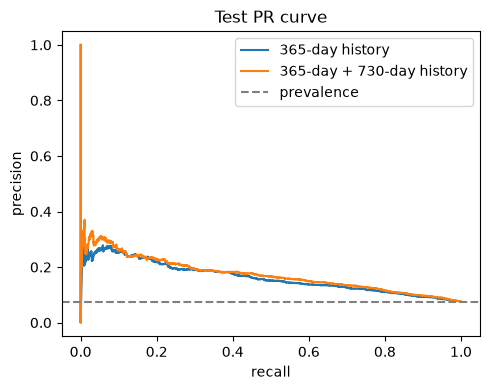

In [12]:
prec_365, rec_365, _ = precision_recall_curve(test["target"], proba_365)
prec_730, rec_730, _ = precision_recall_curve(test["target"], proba_730)

plt.figure(figsize=(5, 4))
plt.plot(rec_365, prec_365, label="365-day history")
plt.plot(rec_730, prec_730, label="365-day + 730-day history")
plt.axhline(test["target"].mean(), linestyle="--", color="gray", label="prevalence")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("Test PR curve")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/logistic_730d_pr_curve.png", dpi=100)
plt.show()

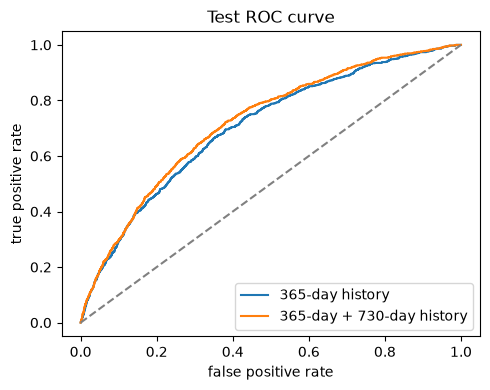

In [13]:
fpr_365, tpr_365, _ = roc_curve(test["target"], proba_365)
fpr_730, tpr_730, _ = roc_curve(test["target"], proba_730)

plt.figure(figsize=(5, 4))
plt.plot(fpr_365, tpr_365, label="365-day history")
plt.plot(fpr_730, tpr_730, label="365-day + 730-day history")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("Test ROC curve")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/logistic_730d_roc_curve.png", dpi=100)
plt.show()

## Coefficients (730-day model)

Standardized features. The 365-day and 730-day window features naturally overlap (`prior_365d_total_infractions` and `prior_730d_total_infractions` describe related things over different windows), so individual coefficients here should be read cautiously, not as separate independent effects.

In [14]:
coefs = pipe_730.named_steps["clf"].coef_[0]
coef_df = pd.DataFrame({"feature": FEATURES_730, "coefficient": coefs})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)
coef_df

,feature,coefficient,abs_coefficient
0,prev_non_pass,-0.630193,0.630193
1,prev_total_infractions,0.499772,0.499772
2,prior_730d_total_infractions,0.438651,0.438651
3,prior_730d_n_non_pass,0.149427,0.149427
4,prev_significant,-0.132180,0.132180
5,prev_crucial,-0.127165,0.127165
6,prior_365d_n_non_pass,0.113969,0.113969
7,prev_minor,-0.103519,0.103519
8,n_inspections_seen_so_far,-0.091690,0.091690
9,prior_730d_n_inspections,-0.074184,0.074184


## Save results

In [15]:
results_730 = pd.DataFrame([
    {"model": "logistic_730d_history", "feature_set": "previous inspection + 365-day + 730-day history (15 features)",
     "val_pr_auc": metrics_730["val_pr_auc"], "val_roc_auc": metrics_730["val_roc_auc"],
     "threshold": metrics_730["threshold"],
     "test_pr_auc": metrics_730["test_pr_auc"], "test_roc_auc": metrics_730["test_roc_auc"],
     "test_precision": metrics_730["test_precision"], "test_recall": metrics_730["test_recall"],
     "test_f1": metrics_730["test_f1"], "test_accuracy": metrics_730["test_accuracy"],
     "train_rows": len(train), "val_rows": len(val), "test_rows": len(test),
     "train_start": train["inspectionDate"].min(), "train_end": train["inspectionDate"].max(),
     "val_start": val["inspectionDate"].min(), "val_end": val["inspectionDate"].max(),
     "test_start": test["inspectionDate"].min(), "test_end": test["inspectionDate"].max()},
])
results_730.to_csv("../outputs/logistic_730d_history_results.csv", index=False)
coef_df.to_csv("../outputs/logistic_730d_history_coefficients.csv", index=False)
print("saved outputs/logistic_730d_history_results.csv")
print("saved outputs/logistic_730d_history_coefficients.csv")

saved outputs/logistic_730d_history_results.csv
saved outputs/logistic_730d_history_coefficients.csv


## Interpretation

Adding the 730-day historical features provided a small additional improvement over the 365-day model (test PR-AUC 0.162 to 0.173, ROC-AUC 0.704 to 0.720), under the identical strict temporal split and target rows. This is a real but modest gain, not a clear breakthrough, most of the predictive value from inspection history seems to already be captured within the most recent year. This remains prediction of the recorded DineSafe Non-Pass outcome, not a measure of true underlying food safety, and nothing here should be read as a causal claim about older history making outcomes better or worse.